# Field Context Lifecycle Hybrid RAG Demo

This notebook shows a query/response sequence rather than only an aggregate result table. It starts from a deliberately cleaned and limited local vector store, uses connectivity resume to fetch relevant online cases, caches those cases into an offline delta pack, and then searches again locally to show how the offline context has become richer. Each search-history query is embedded with `openai/clip-vit-base-patch32` using `image-text` inputs.


## Information flow

```mermaid
flowchart LR
  Worker[Field worker photo + text query] --> CLIP[Local CLIP image+text embedding]
  CLIP --> Offline1[Initial offline SQLite pack]
  Offline1 --> Phi1[Phi-4-mini conservative answer]
  Offline1 --> History[Search history + missed/specific intent]
  History -->|connectivity resumes| Online[Azure AI Search full enriched index]
  Online --> Select[Select relevant online-only cases]
  Select --> Delta[Signed/local offline delta pack]
  Delta --> Offline2[Enriched offline search]
  Offline2 --> Phi2[Phi-4-mini richer cited answer]
```


## Context states

| State | What is available | Purpose |
| --- | --- | --- |
| Initial offline | INC-001, INC-002, INC-005 | Small resource-limited pack for common/high-priority cases. |
| Enriched offline after sync | INC-001, INC-002, INC-005, ONL-007, ONL-010, ONL-011 | Local pack after connectivity resumes and relevant online cases are cached. |
| Online | Full Azure AI Search index | Broader corpus and fresher context when network is available. |


Online cases cached for later offline use 
 
 ONL-007 - Water ingress approaching temporary electrical riser Severity: critical Synced into offline delta pack for later disconnected search. 
 ONL-010 - Temporary works prop shows visible deformation Severity: critical Synced into offline delta pack for later disconnected search. 
 ONL-011 - Confined-space gas detector alarm triggered during drainage inspection Severity: critical Synced into offline delta pack for later disconnected search.
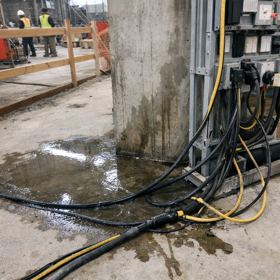
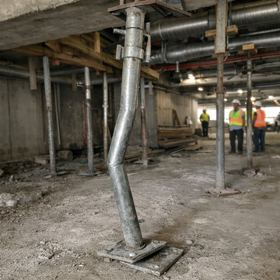
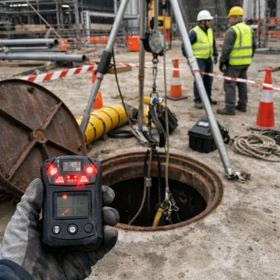

In [1]:
from IPython.display import HTML, display
# Synced online-only cases are embedded as thumbnails so the notebook remains self-contained.
display(HTML(synced_case_gallery_html))


## Query/response sequence: initial offline -> enriched offline -> online

### 1. Known concrete defect already cached

**Worker query:** A column face has honeycombing and exposed aggregate after formwork removal.

**Query image:** `inc_002_concrete_column_honeycombing_detected_after_.png`

**Initial offline retrieval**

| Top-3 local evidence | Model response from initial offline context |
| --- | --- |
| 1. INC-002 - Concrete column honeycombing detected after form removal (`0.8858`)<br>2. INC-001 - Basement wall water ingress observed at construction joint (`0.7387`)<br>3. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.7381`) | This looks closest to [INC-002] Concrete column honeycombing detected after form removal (severity: high).<br>What I can ground from the local evidence: A reinforced concrete column shows honeycombing in the lower lift area following formwork removal. The defect is localized but extends over enough surface area to indicate poor consolidation or leakage during casting, requiring assessment of depth and impact on cover.<br>Likely cause to check: Probable inadequate vibration, congested reinforcement impeding flow, grout loss through formwork joints, or improper concrete placement technique.<br>Recommended next actions:<br>1. Sound the affected area and carry out a depth assessment by engineer or competent inspector<br>2. Verify reinforcement cover and determine whether structural repair is required<br>3. Review pour sequence, vibration records, and formwork tightness for the affected lift<br>4. Protect the ar... |

**Enriched offline retrieval after connectivity sync**

| Top-3 local evidence after sync | Model response after offline cache enrichment |
| --- | --- |
| 1. INC-002 - Concrete column honeycombing detected after form removal (`0.8858`)<br>2. ONL-010 - Temporary works prop shows visible deformation (`0.7790`)<br>3. INC-001 - Basement wall water ingress observed at construction joint (`0.7387`) | This looks closest to [INC-002] Concrete column honeycombing detected after form removal (severity: high).<br>What I can ground from the local evidence: A reinforced concrete column shows honeycombing in the lower lift area following formwork removal. The defect is localized but extends over enough surface area to indicate poor consolidation or leakage during casting, requiring assessment of depth and impact on cover.<br>Likely cause to check: Probable inadequate vibration, congested reinforcement impeding flow, grout loss through formwork joints, or improper concrete placement technique.<br>Recommended next actions:<br>1. Sound the affected area and carry out a depth assessment by engineer or competent inspector<br>2. Verify reinforcement cover and determine whether structural repair is required<br>3. Review pour sequence, vibration records, and formwork tightness for the affected lift<br>4. Protect the ar... |

**Online result used during connectivity resume**

| Top-3 Azure AI Search evidence | Cached for later offline use |
| --- | --- |
| 1. INC-002 - Concrete column honeycombing detected after form removal (`0.0333`)<br>2. ONL-009 - Concrete spalling at slab edge after formwork striking (`0.0328`)<br>3. INC-006 - Hairline crack observed near lift core wall opening (`0.0302`) | none |

### 2. Water ingress becomes electrical safety issue

**Worker query:** Water seepage is close to a temporary electrical riser in the basement after rain.

**Query image:** `onl_007_water_ingress_approaching_temporary_electric.png`

**Initial offline retrieval**

| Top-3 local evidence | Model response from initial offline context |
| --- | --- |
| 1. INC-001 - Basement wall water ingress observed at construction joint (`0.7836`)<br>2. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.7252`)<br>3. INC-002 - Concrete column honeycombing detected after form removal (`0.7222`) | This looks closest to [INC-001] Basement wall water ingress observed at construction joint (severity: high).<br>What I can ground from the local evidence: Active water ingress is visible at the basement wall joint, with staining extending below the suspect construction joint and moisture tracking toward the floor slab edge. No immediate structural distress is evident, but the leakage suggests a compromised waterproofing detail or joint seal failure.<br>Likely cause to check: Likely discontinuity in waterproofing membrane, inadequate joint preparation, or failed waterstop/sealant at a construction joint combined with hydrostatic pressure.<br>Recommended next actions:<br>1. Mark and photograph the full extent of seepage and note elevation/chainage references<br>2. Inspect the joint detailing, membrane continuity, and any penetrations or tie-hole repairs<br>3. Check adjacent drainage, sump operation, and ex... |

**Enriched offline retrieval after connectivity sync**

| Top-3 local evidence after sync | Model response after offline cache enrichment |
| --- | --- |
| 1. ONL-007 - Water ingress approaching temporary electrical riser (`0.8967`)<br>2. INC-001 - Basement wall water ingress observed at construction joint (`0.7836`)<br>3. ONL-010 - Temporary works prop shows visible deformation (`0.7708`) | This looks closest to [ONL-007] Water ingress approaching temporary electrical riser (severity: critical).<br>What I can ground from the local evidence: Water ingress is occurring close to a temporary electrical riser, creating an immediate risk of electrical shock, short circuit, and service interruption. The condition is time-sensitive because the seepage path may reach live distribution components if not isolated.<br>Likely cause to check: Likely failed waterproofing, rainwater intrusion, or uncontrolled surface drainage compounded by insufficient protection and routing of temporary electrical infrastructure.<br>Recommended next actions:<br>1. Isolate the affected temporary electrical circuit and verify de-energization by a competent person<br>2. Keep personnel away from the wet area and establish a controlled exclusion zone<br>3. Identify the water source and apply temporary diversion, containment, o... |

**Online result used during connectivity resume**

| Top-3 Azure AI Search evidence | Cached for later offline use |
| --- | --- |
| 1. ONL-007 - Water ingress approaching temporary electrical riser (`0.0333`)<br>2. INC-001 - Basement wall water ingress observed at construction joint (`0.0328`)<br>3. ONL-010 - Temporary works prop shows visible deformation (`0.0323`) | ONL-007 |

### 3. Temporary works prop not in local pack

**Worker query:** A temporary works prop is visibly bowed and the base plate has shifted under slab load.

**Query image:** `onl_010_temporary_works_prop_shows_visible_deformati.png`

**Initial offline retrieval**

| Top-3 local evidence | Model response from initial offline context |
| --- | --- |
| 1. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.7769`)<br>2. INC-002 - Concrete column honeycombing detected after form removal (`0.7552`)<br>3. INC-001 - Basement wall water ingress observed at construction joint (`0.6973`) | This looks closest to [INC-005] Unsafe open edge adjacent to scaffold access point (severity: critical).<br>What I can ground from the local evidence: An open edge is present immediately adjacent to scaffold access, creating a high-risk fall exposure for workers transitioning between the scaffold and the slab. The hazard is uncontrolled and requires immediate protection or access restriction.<br>Likely cause to check: Likely removal or omission of edge protection during sequencing, inadequate supervision, or incomplete scaffold-to-structure interface controls.<br>Recommended next actions:<br>1. Stop access to the affected route until edge protection is installed or alternative safe access is provided<br>2. Install compliant guardrails, toe boards, and controlled access measures at the perimeter<br>3. Inspect scaffold tie-ins, landing condition, and opening protections for related defects<br>4. Brief all nea... |

**Enriched offline retrieval after connectivity sync**

| Top-3 local evidence after sync | Model response after offline cache enrichment |
| --- | --- |
| 1. ONL-010 - Temporary works prop shows visible deformation (`0.8715`)<br>2. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.7769`)<br>3. ONL-007 - Water ingress approaching temporary electrical riser (`0.7694`) | This looks closest to [ONL-010] Temporary works prop shows visible deformation (severity: critical).<br>What I can ground from the local evidence: A temporary works prop is visibly deformed, indicating possible overload, instability, or foundation settlement. This is a critical condition because failure of temporary support could trigger partial collapse or sudden load redistribution.<br>Likely cause to check: Possible overload from premature loading, inadequate bracing, incorrect prop capacity selection, or base settlement on an insufficient bearing surface.<br>Recommended next actions:<br>1. Immediately clear personnel from the supported area and prohibit loading on the temporary arrangement<br>2. Inspect all related props, bracing, and bearing conditions for signs of instability or settlement<br>3. Verify the approved temporary works design against actual loading and geometry<br>4. Install additional sup... |

**Online result used during connectivity resume**

| Top-3 Azure AI Search evidence | Cached for later offline use |
| --- | --- |
| 1. ONL-010 - Temporary works prop shows visible deformation (`0.0333`)<br>2. INC-006 - Hairline crack observed near lift core wall opening (`0.0320`)<br>3. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.0313`) | ONL-010 |

### 4. Confined space gas alarm not in local pack

**Worker query:** A gas detector alarms before manhole drainage inspection and confined space entry.

**Query image:** `onl_011_confined_space_gas_detector_alarm_triggered_.png`

**Initial offline retrieval**

| Top-3 local evidence | Model response from initial offline context |
| --- | --- |
| 1. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.7006`)<br>2. INC-002 - Concrete column honeycombing detected after form removal (`0.6784`)<br>3. INC-001 - Basement wall water ingress observed at construction joint (`0.6449`) | This looks closest to [INC-005] Unsafe open edge adjacent to scaffold access point (severity: critical).<br>What I can ground from the local evidence: An open edge is present immediately adjacent to scaffold access, creating a high-risk fall exposure for workers transitioning between the scaffold and the slab. The hazard is uncontrolled and requires immediate protection or access restriction.<br>Likely cause to check: Likely removal or omission of edge protection during sequencing, inadequate supervision, or incomplete scaffold-to-structure interface controls.<br>Recommended next actions:<br>1. Stop access to the affected route until edge protection is installed or alternative safe access is provided<br>2. Install compliant guardrails, toe boards, and controlled access measures at the perimeter<br>3. Inspect scaffold tie-ins, landing condition, and opening protections for related defects<br>4. Brief all nea... |

**Enriched offline retrieval after connectivity sync**

| Top-3 local evidence after sync | Model response after offline cache enrichment |
| --- | --- |
| 1. ONL-011 - Confined-space gas detector alarm triggered during drainage inspection (`0.9168`)<br>2. ONL-007 - Water ingress approaching temporary electrical riser (`0.7369`)<br>3. ONL-010 - Temporary works prop shows visible deformation (`0.7270`) | This looks closest to [ONL-011] Confined-space gas detector alarm triggered during drainage inspection (severity: critical).<br>What I can ground from the local evidence: A gas detector alarm activated during drainage inspection, indicating an unsafe atmosphere in or near the confined space. The condition may involve oxygen deficiency, toxic gas, or flammable gas, and no further entry should continue until the atmosphere is proven safe.<br>Likely cause to check: Likely accumulation of sewer gas, inadequate ventilation, residual biological decay, or disturbed sediment releasing hazardous vapors.<br>Recommended next actions:<br>1. Withdraw all personnel from the confined space area and prevent re-entry<br>2. Test atmosphere from outside the space using calibrated equipment at multiple levels<br>3. Implement forced ventilation only if approved and appropriate for the hazard identified<br>4. Confirm rescue arra... |

**Online result used during connectivity resume**

| Top-3 Azure AI Search evidence | Cached for later offline use |
| --- | --- |
| 1. ONL-011 - Confined-space gas detector alarm triggered during drainage inspection (`0.0333`)<br>2. ONL-008 - Falling object exclusion zone breached beneath overhead work (`0.0311`)<br>3. ONL-010 - Temporary works prop shows visible deformation (`0.0309`) | ONL-011 |


## Aggregate lifecycle result

| Search-history scenario | Initial offline top | Enriched offline top after sync | Online top | Synced into offline delta |
| --- | --- | --- | --- | --- |
| Known concrete defect already cached | INC-002 | INC-002 | INC-002 | none |
| Water ingress becomes electrical safety issue | INC-001 | ONL-007 | ONL-007 | ONL-007 |
| Temporary works prop not in local pack | INC-005 | ONL-010 | ONL-010 | ONL-010 |
| Confined space gas alarm not in local pack | INC-005 | ONL-011 | ONL-011 | ONL-011 |


## Full online search with more queries

| Online query | Top-3 online results |
| --- | --- |
| water seepage near temporary electrical riser | 1. ONL-007 - Water ingress approaching temporary electrical riser (`0.0333`)<br>2. INC-001 - Basement wall water ingress observed at construction joint (`0.0325`)<br>3. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.0164`) |
| falling object exclusion zone breach below overhead works | 1. ONL-008 - Falling object exclusion zone breached beneath overhead work (`0.0333`)<br>2. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.0323`)<br>3. ONL-010 - Temporary works prop shows visible deformation (`0.0323`) |
| concrete spalling at slab edge after formwork striking | 1. ONL-009 - Concrete spalling at slab edge after formwork striking (`0.0333`)<br>2. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.0325`)<br>3. INC-006 - Hairline crack observed near lift core wall opening (`0.0318`) |
| temporary works prop deformation under slab load | 1. ONL-010 - Temporary works prop shows visible deformation (`0.0333`)<br>2. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.0315`)<br>3. ONL-007 - Water ingress approaching temporary electrical riser (`0.0164`) |
| confined space gas detector alarm before manhole entry | 1. ONL-011 - Confined-space gas detector alarm triggered during drainage inspection (`0.0333`)<br>2. ONL-008 - Falling object exclusion zone breached beneath overhead work (`0.0320`)<br>3. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.0315`) |
| mobile crane boom operating near overhead service line | 1. ONL-012 - Mobile crane lift conducted near overhead service line (`0.0333`)<br>2. ONL-008 - Falling object exclusion zone breached beneath overhead work (`0.0328`)<br>3. INC-006 - Hairline crack observed near lift core wall opening (`0.0161`) |
| MEP duct clashes with ceiling service zone | 1. INC-004 - MEP duct coordination clash at ceiling void (`0.0333`)<br>2. ONL-008 - Falling object exclusion zone breached beneath overhead work (`0.0325`)<br>3. ONL-010 - Temporary works prop shows visible deformation (`0.0302`) |
| crack near lift core wall opening after concrete placement | 1. INC-006 - Hairline crack observed near lift core wall opening (`0.0333`)<br>2. ONL-009 - Concrete spalling at slab edge after formwork striking (`0.0320`)<br>3. INC-005 - Unsafe open edge adjacent to scaffold access point (`0.0311`) |


## Where Phi-4-mini helps in the hybrid scenario

Local CLIP handles the image+text query embedding. Phi-4-mini-instruct runs after retrieval in both offline passes. Because Phi-4-mini-instruct is text-only, it receives cited evidence rather than raw pixels. Before sync, it should be conservative: cite the limited evidence, explain that the local pack may not contain a specialist case, and escalate. After sync, it can use the newly cached online-only case to produce a more specific response while still operating offline. If direct image+text reasoning inside the SLM is required, replace the answer generator with `Phi-4-multimodal-instruct`.

This executed lifecycle report used `template` as the answer generator.

The online path can use Azure AI Search and a larger/cloud model when available, but the key hybrid behavior is that the useful online result becomes a local evidence record for the next disconnected search.
